In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
plt.rcParams["figure.figsize"] = (10,5)

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving inventory_data.csv to inventory_data.csv


In [ ]:
df = pd.read_csv(list(uploaded.keys())[0])
df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn
1,2022-01-01,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,0,66.16,Autumn
2,2022-01-01,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,1,31.32,Summer
3,2022-01-01,S001,P0004,Toys,North,469,61,164,62.18,32.72,10,Cloudy,1,34.74,Autumn
4,2022-01-01,S001,P0005,Electronics,East,166,14,135,9.26,73.64,0,Sunny,0,68.95,Summer


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df.shape

(73100, 15)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73100 entries, 0 to 73099
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                73100 non-null  object 
 1   Store ID            73100 non-null  object 
 2   Product ID          73100 non-null  object 
 3   Category            73100 non-null  object 
 4   Region              73100 non-null  object 
 5   Inventory Level     73100 non-null  int64  
 6   Units Sold          73100 non-null  int64  
 7   Units Ordered       73100 non-null  int64  
 8   Demand Forecast     73100 non-null  float64
 9   Price               73100 non-null  float64
 10  Discount            73100 non-null  int64  
 11  Weather Condition   73100 non-null  object 
 12  Holiday/Promotion   73100 non-null  int64  
 13  Competitor Pricing  73100 non-null  float64
 14  Seasonality         73100 non-null  object 
dtypes: float64(3), int64(5), object(7)
memory usage: 8.4+

In [ ]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Date,73100,731,2024-01-01,100,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Store ID,73100,5,S001,14620,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product ID,73100,20,P0001,3655,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Category,73100,5,Furniture,14699,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Region,73100,4,East,18349,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Inventory Level,73100.0,NaN,NaN,NaN,274.469877,129.949514,50.0,162.0,273.0,387.0,500.0
Units Sold,73100.0,NaN,NaN,NaN,136.46487,108.919406,0.0,49.0,107.0,203.0,499.0
Units Ordered,73100.0,NaN,NaN,NaN,110.004473,52.277448,20.0,65.0,110.0,155.0,200.0
Demand Forecast,73100.0,NaN,NaN,NaN,141.49472,109.254076,-9.99,53.67,113.015,208.0525,518.55
Price,73100.0,NaN,NaN,NaN,55.135108,26.021945,10.0,32.65,55.05,77.86,100.0


In [ ]:
df.isna().sum().sort_values(ascending=False)

,0
Date,0
Store ID,0
Product ID,0
Category,0
Region,0
Inventory Level,0
Units Sold,0
Units Ordered,0
Demand Forecast,0
Price,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

In [ ]:
df[['Date']].head()

,Date
0,2022-01-01
1,2022-01-01
2,2022-01-01
3,2022-01-01
4,2022-01-01


In [ ]:
df = df.dropna(subset=['Date'])

In [ ]:
df['revenue'] = df['Price'] * df['Units Sold']
df['month'] = df['Date'].dt.to_period('M').astype(str)
df['day_name'] = df['Date'].dt.day_name()

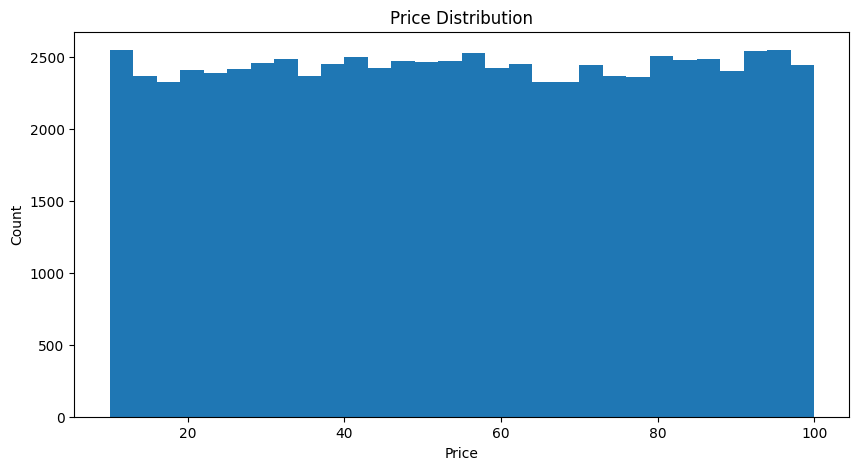

In [ ]:
plt.hist(df['Price'], bins=30)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

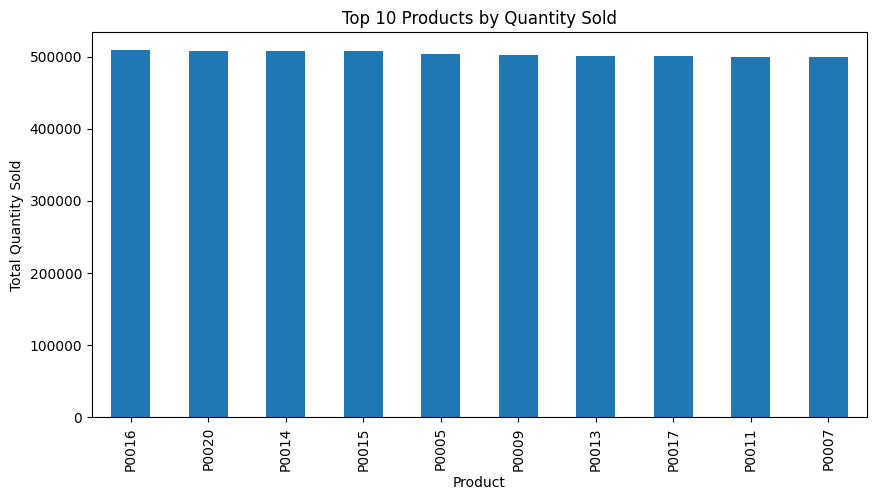

In [ ]:
top_products = df.groupby('Product ID')['Units Sold'].sum().sort_values(ascending=False).head(10)

top_products.plot(kind='bar')
plt.title("Top 10 Products by Quantity Sold")
plt.xlabel("Product")
plt.ylabel("Total Quantity Sold")
plt.show()

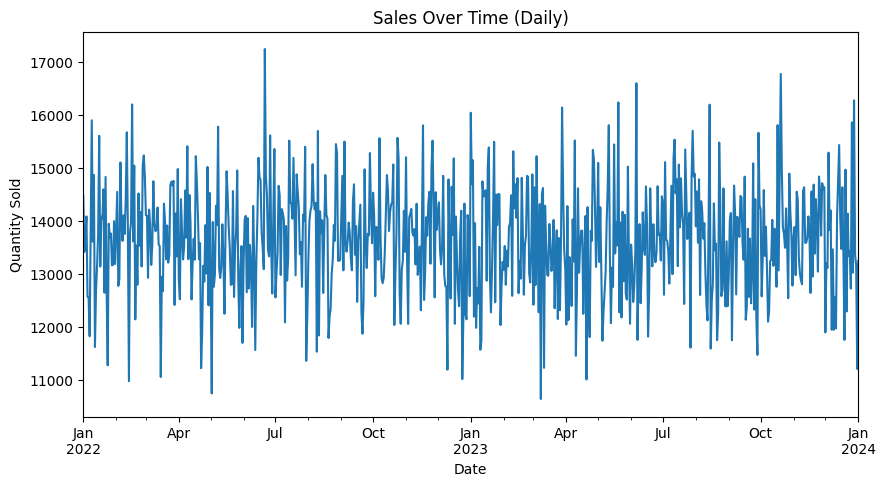

In [ ]:
daily_sales = df.groupby('Date')['Units Sold'].sum()

daily_sales.plot()
plt.title("Sales Over Time (Daily)")
plt.xlabel("Date")
plt.ylabel("Quantity Sold")
plt.show()

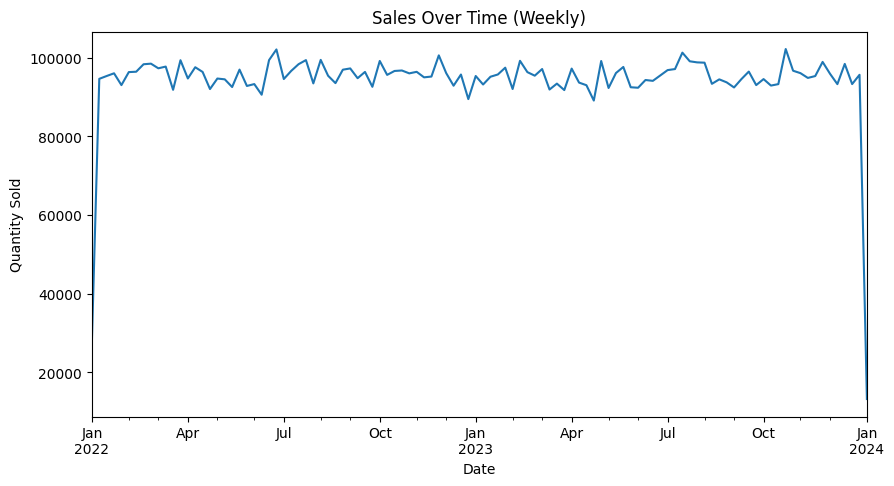

In [ ]:
weekly_sales = df.set_index('Date')['Units Sold'].resample('W').sum()
weekly_sales.plot()
plt.title("Sales Over Time (Weekly)")
plt.xlabel("Date")
plt.ylabel("Quantity Sold")
plt.show()

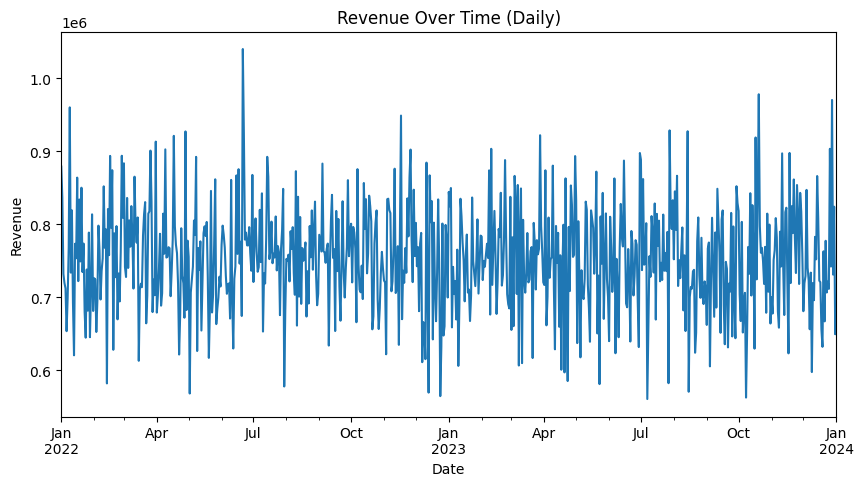

In [ ]:
daily_revenue = df.groupby('Date')['revenue'].sum()
daily_revenue.plot()
plt.title("Revenue Over Time (Daily)")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.show()

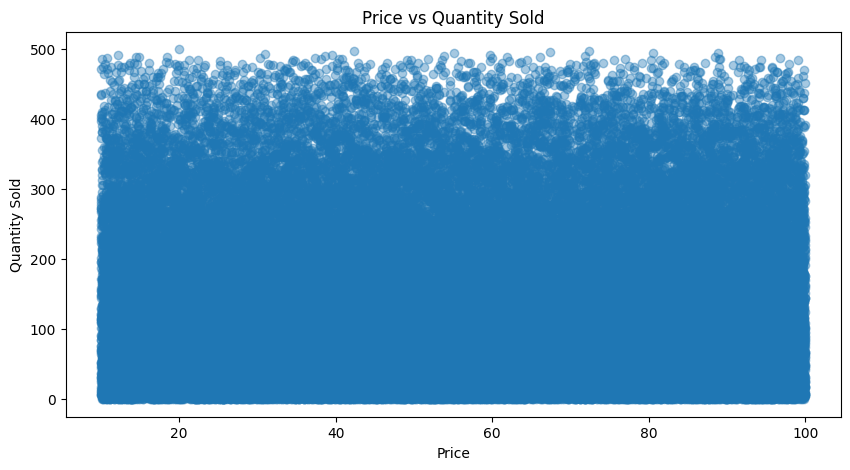

In [ ]:
plt.scatter(df['Price'], df['Units Sold'], alpha=0.4)
plt.title("Price vs Quantity Sold")
plt.xlabel("Price")
plt.ylabel("Quantity Sold")
plt.show()

In [ ]:
df[['Price','Units Sold']].corr()

,Price,Units Sold
Price,1.000000,0.001082
Units Sold,0.001082,1.000000


In [ ]:
df[['Price','Units Sold']].corr()

,Price,Units Sold
Price,1.000000,0.001082
Units Sold,0.001082,1.000000


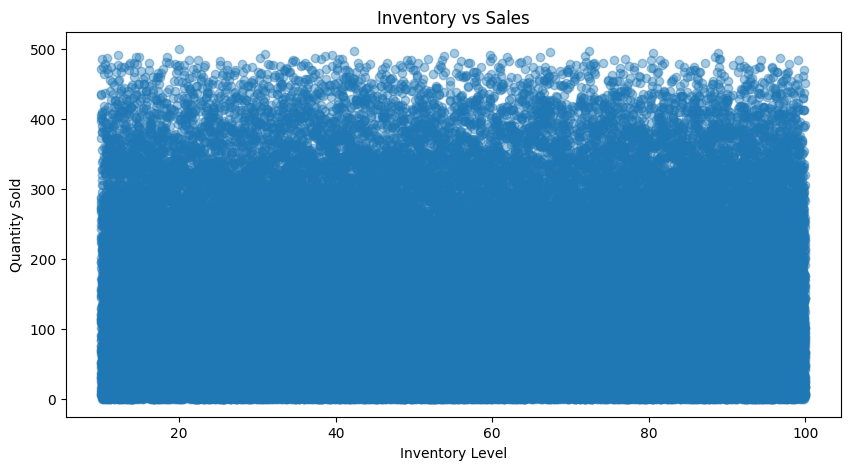

In [ ]:
plt.scatter(df['Price'], df['Units Sold'], alpha=0.4)
plt.title("Inventory vs Sales")
plt.xlabel("Inventory Level")
plt.ylabel("Quantity Sold")
plt.show()

In [ ]:
prod_stats = df.groupby('Product ID').agg(
    total_sold=('Units Sold','sum'),
    avg_price=('Price','mean'),
    total_revenue=('revenue','sum')
).reset_index()

prod_stats.head()

,Product ID,total_sold,avg_price,total_revenue
0,P0001,498061,54.547330,27477692.24
1,P0002,487827,55.267726,26797736.64
2,P0003,493279,54.885759,27057650.52
3,P0004,495501,55.538966,27477122.68
4,P0005,503648,55.023590,27916663.02


In [ ]:
df.to_csv("eda_clean_dataset.csv", index=False)

In [ ]:
from google.colab import files
files.download("eda_clean_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

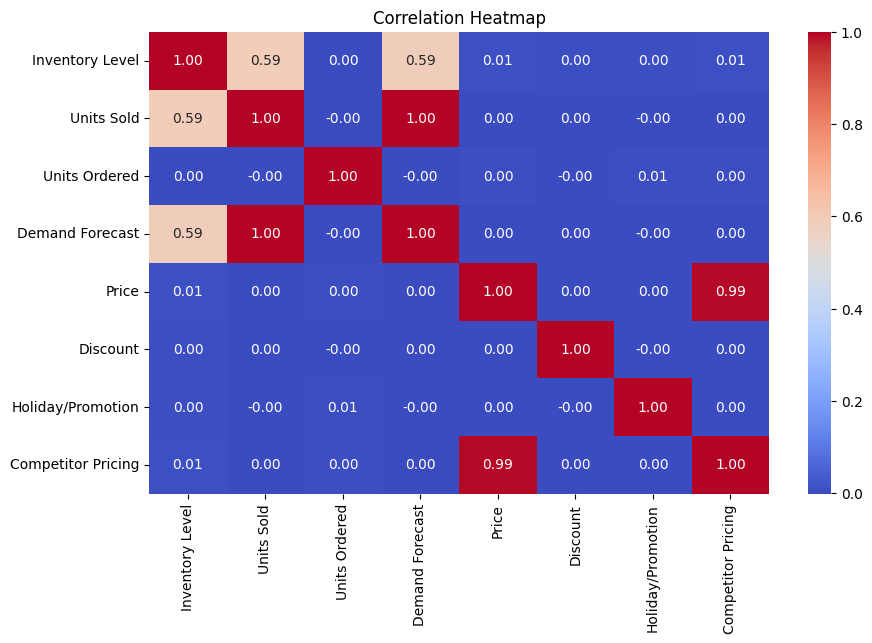

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
data = pd.read_csv("inventory_data.csv")

# Select only numeric columns
numeric_data = data.select_dtypes(include=['number'])

# Calculate correlation
correlation = numeric_data.corr()

# Plot heatmap
plt.figure(figsize=(10,6))
sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()